# Markov Chain Monte Carlo

Markov Chain Monte Carlo, or MCMC, combines the concepts of Monte Carlo sampling with Markov Chains' property of converging to a steady state. This allows sampling draws from any, even unknown, posterior distribution. Let's check your intuition about MCMC!



<center><img src="images/04.01.png"  style="width: 400px, height: 300px;"/></center>

# Sampling posterior draws

Tired of working for the central government and for the marketing company, you take a new job as a data analyst for your city's local authorities. The city operates a bike-sharing system in the city and they ask you to predict the number of bikes rented per day to plan staff and repairs accordingly.

You have been given some data on the number of rented vehicles per day, temperature, humidity, wind speed, and whether the day was a working day:
```
     work_day      temp  humidity  wind_speed  num_bikes
0           0  0.344167  0.805833    0.160446      0.985
1           0  0.363478  0.696087    0.248539      0.801
..        ...       ...       ...         ...        ...
698         1  0.280870  0.555652    0.115522      5.323
699         1  0.298333  0.649583    0.058471      5.668
```
Try building a regression model to predict num_bikes using the bikes DataFrame

<center><img src="images/04.02.png"  style="width: 400px, height: 300px;"/></center>


# Inspecting posterior draws

You continue working on your task to predict the number of bikes rented per day in a bike-sharing system. The posterior draws from your regression model which you sampled before are available in your workspace as trace_1.

You know that after obtaining the posteriors, it is best practice to take a look at them to see if they make sense and if the MCMC process has converged successfully. In this exercise, you will create two plots visualizing posterior draws and summarize them in a table. Let's inspect our posteriors!

In [1]:
import pandas as pd
bikes = pd.read_csv("dataset/bikes_test.csv")
bikes.head()


,work_day,temp,humidity,wind_speed,num_bikes
0,0,0.265833,0.687917,0.175996,2.947
1,1,0.282609,0.622174,0.153800,3.784
2,1,0.354167,0.496250,0.147379,4.375
3,1,0.256667,0.722917,0.133721,2.802
4,1,0.265000,0.562083,0.194037,3.830


In [4]:
import pymc3 as pm
formula = "num_bikes ~ temp + work_day"

with pm.Model() as model_1:
    # pm.GLM.from_formula(formula, data=bikes)
    # trace_1 = pm.sample(draws=1000, tune=500)
    pm.GLM.from_formula(formula, data=bikes, family=pm.glm.families.Normal())

    # Increase the number of tuning steps and draw more samples
    trace_1 = pm.sample(draws=1000, tune=10000, target_accept=0.99,  return_inferencedata=True)

The glm module is deprecated and will be removed in version 4.0
We recommend to instead use Bambi https://bambinos.github.io/bambi/


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sd, work_day, temp, Intercept]


Sampling 4 chains for 10_000 tune and 1_000 draw iterations (40_000 + 4_000 draws total) took 243 seconds.
The number of effective samples is smaller than 25% for some parameters.


C:\Users\88016\AppData\Local\Temp/ipykernel_31964/2334200936.py:6: DeprecationWarning: The function `traceplot` from PyMC3 is just an alias for `plot_trace` from ArviZ. Please switch to `pymc3.plot_trace` or `arviz.plot_trace`.
  pm.traceplot(trace_1)


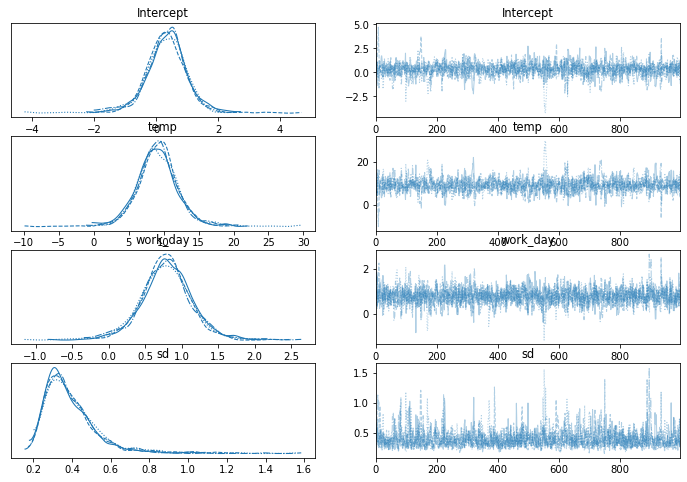

C:\Users\88016\AppData\Local\Temp/ipykernel_31964/2334200936.py:10: DeprecationWarning: The function `forestplot` from PyMC3 is just an alias for `plot_forest` from ArviZ. Please switch to `pymc3.plot_forest` or `arviz.plot_forest`.
  pm.forestplot(trace_1)


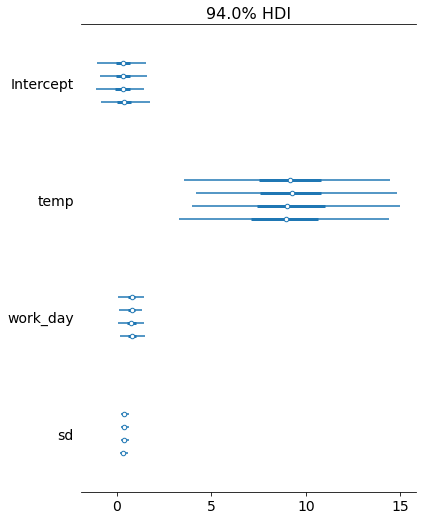

In [5]:
# Import pymc3
import pymc3 as pm
import matplotlib.pyplot as plt

# Draw a trace plot of trace_1
pm.traceplot(trace_1)
plt.show()

# Draw a forest plot of trace_1
pm.forestplot(trace_1)
plt.show()

In [6]:
pm.summary(trace_1)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,0.324,0.682,-0.999,1.562,0.023,0.016,988.0,1141.0,1.0
temp,9.183,3.009,3.876,14.905,0.107,0.081,891.0,1049.0,1.0
work_day,0.788,0.351,0.124,1.459,0.010,0.007,1386.0,1225.0,1.0
sd,0.394,0.144,0.199,0.637,0.005,0.003,1107.0,1117.0,1.0


# Comparing models with WAIC

Now that you have successfully built the first, basic model, you take another look at the data at your disposal. You notice a variable called `wind_speed`. This could be a great predictor of the numbers of bikes rented! Cycling against the wind is not that much fun, is it?

Is your new `model_2` better than `model_1`, the one without wind speed? Compare the two models using Widely Applicable Information Criterion, or WAIC, to find out!

In [7]:
formula = "num_bikes ~ temp + work_day + wind_speed"

with pm.Model() as model_2:
    # pm.GLM.from_formula(formula, data=bikes)
    # trace_2 = pm.sample(draws=1000, tune=1000)
    pm.GLM.from_formula(formula, data=bikes, family=pm.glm.families.Normal())

    # Increase the number of tuning steps and draw more samples
    trace_2 = pm.sample(draws=1000, tune=10000, target_accept=0.94,  return_inferencedata=True)

The glm module is deprecated and will be removed in version 4.0
We recommend to instead use Bambi https://bambinos.github.io/bambi/
The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sd, wind_speed, work_day, temp, Intercept]


Sampling 4 chains for 10_000 tune and 1_000 draw iterations (40_000 + 4_000 draws total) took 499 seconds.
The number of effective samples is smaller than 25% for some parameters.


c:\Users\88016\anaconda3\envs\env_py\lib\site-packages\arviz\stats\stats.py:1661: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
c:\Users\88016\anaconda3\envs\env_py\lib\site-packages\arviz\stats\stats.py:1661: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
C:\Users\88016\AppData\Local\Temp/ipykernel_31964/725617364.py:9: DeprecationWarning: The function `compareplot` from PyMC3 is an alias for `plot_compare` from ArviZ. It also applies some kwarg replacements. Nevertheless, please switch to `pymc3.plot_compare` or `arviz.plot_compare`.
  pm.compareplot(comparison, textsize=20)


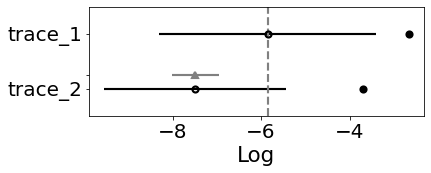

In [8]:
# Gather trace_1 and trace_2 into a dictionary
traces_dict = {"trace_1" : trace_1, "trace_2" : trace_2}


# Create a comparison table based on WAIC
comparison = pm.compare(traces_dict, ic="waic")

# Draw a comparison plot
pm.compareplot(comparison, textsize=20)
plt.show()

# Sample from predictive density

Finally! Your job is to predict the number of bikes rented per day, and you are almost there. You have fitted the model and verified the quality of parameter draws. You have also chosen the better of the two competing models based on the WAIC. Now, it's time to use your best model to make predictions!

A couple of new observations, not seen by the model, have been collected in a DataFrame named bikes_test. For each of them, we know the true number of bikes rented, which will allow us to evaluate model performance. In this exercise, you will get familiar with the test data and generate predictive draws for every test observation.

In [9]:
bikes_test = bikes
# Print bikes_test head
print(bikes_test.head())

# Define the formula
formula = "num_bikes ~ temp + work_day + wind_speed"

# Generate predictive draws
with pm.Model() as model:
    pm.GLM.from_formula(formula, data=bikes_test)
    posterior_predictive = pm.fast_sample_posterior_predictive(trace_2)


The glm module is deprecated and will be removed in version 4.0
We recommend to instead use Bambi https://bambinos.github.io/bambi/


   work_day      temp  humidity  wind_speed  num_bikes
0         0  0.265833  0.687917    0.175996      2.947
1         1  0.282609  0.622174    0.153800      3.784
2         1  0.354167  0.496250    0.147379      4.375
3         1  0.256667  0.722917    0.133721      2.802
4         1  0.265000  0.562083    0.194037      3.830


# Estimating test error

Now that you have your posterior_predictive (available to you in your workspace), you can evaluate model performance on new data. To do this, you will need to loop over the test observations, and for each of them, compute the prediction error as the difference between the predictive distribution for this observation and the actual, true value. This will give you the distribution of your model's error, which you can then visualize.

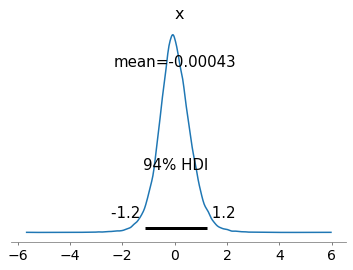

In [10]:
import numpy as np
# Initialize errors
errors = []

# Iterate over rows of bikes_test to compute error per row
for index, test_example in bikes_test.iterrows():
    error = posterior_predictive["y"][:, index] - test_example["num_bikes"]
    errors.append(error)

# Reshape errors
error_distribution = np.array(errors).reshape(-1) # Flatten into 1 array

# Plot the error distribution
pm.plot_posterior(error_distribution) # Visualize error distribution
plt.show()

# Fitting the model

You can use a linear regression model to estimate the avocado price elasticity. The regression formula should be:

`volume ~ N (beta_0 + beta_1 * price + beta_2 * organic_type, std)`

Here, 
`beta_1` will be the price elasticity, that is the impact of price on sales. You will assume that the elasticity is the same for regular and organic avocados. You also expect it to be negative: the higher the price, the lower the sales, that's the case for most goods. To incorporate this prior knowledge into the model, you decide to use a normal distribution with mean -80 as the prior for price. How would you build such a model?

<center><img src="images/04.03.png"  style="width: 400px, height: 300px;"/></center>


# Inspecting the model

Well done getting the model-building right! The trace is available in your workspace and, following the best practices, you will now inspect the posterior draws to see if there are any convergence issues. Next, you will extract each model parameter from the trace and summarize it with its posterior mean. These posterior means will come in handy later, when you will be making predictions with the model. Let's take a look at the parameter draws!

C:\Users\88016\AppData\Local\Temp/ipykernel_31964/2768018812.py:2: DeprecationWarning: The function `traceplot` from PyMC3 is just an alias for `plot_trace` from ArviZ. Please switch to `pymc3.plot_trace` or `arviz.plot_trace`.
  pm.traceplot(trace_2)


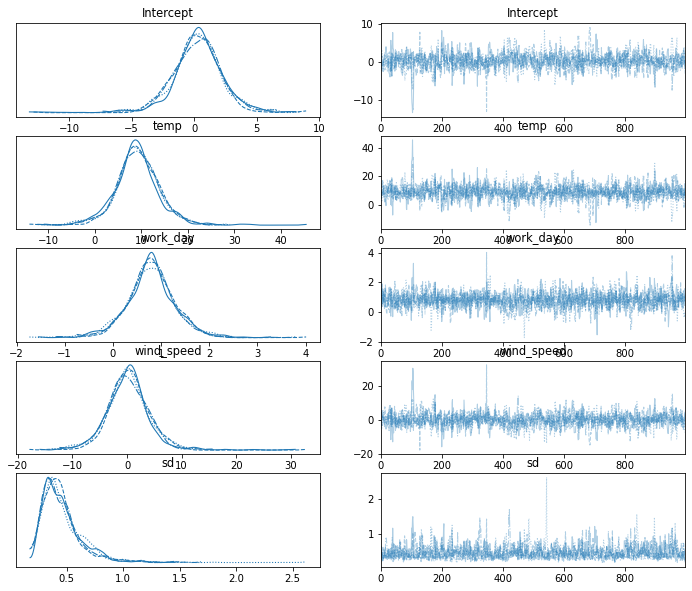

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
Intercept   0.300  1.973  -3.498    3.815      0.067    0.047     867.0   
temp        9.163  4.734   0.808   18.962      0.143    0.103    1149.0   
work_day    0.793  0.497  -0.175    1.722      0.014    0.010    1231.0   
wind_speed  0.137  3.890  -6.724    7.871      0.133    0.094     849.0   
sd          0.455  0.181   0.207    0.784      0.006    0.004     797.0   

            ess_tail  r_hat  
Intercept     1108.0    1.0  
temp          1246.0    1.0  
work_day      1270.0    1.0  
wind_speed    1164.0    1.0  
sd            1397.0    1.0  


In [11]:
# Draw a trace plot of trace
pm.traceplot(trace_2)
plt.show()

# Print a summary of trace
summary = pm.summary(trace_2)
print(summary)

In [15]:
print(*trace_2)
print(*trace_2["posterior"])

posterior log_likelihood sample_stats observed_data
Intercept temp work_day wind_speed sd


In [19]:
# # Get each parameter's posterior mean
# intercept_mean = np.mean( trace.get_values("Intercept")) 
# organic_mean = np.mean( trace.get_values("type_organic")) 
# price_mean = np.mean( trace.get_values("price")) 
# sd_mean = np.mean( trace.get_values("sd")) 


# Get each parameter's posterior mean
intercept_mean = np.mean(trace_2["posterior"]["Intercept"])
temp_mean = np.mean(trace_2["posterior"]["temp"]) 
work_day_mean = np.mean(trace_2["posterior"]["work_day"]) 
wind_speed_mean = np.mean(trace_2["posterior"]["wind_speed"]) 
sd_mean = np.mean(trace_2["posterior"]["sd"]) 

# Optimizing the price

Great job on fitting and inspecting the model! Now, down to business: your boss asks you to provide the avocado price that would yield the largest profit, and to state what profit can be expected. Also, they want the price to be divisible by $0.25 so that the customers can easily pay with quarters.

In this exercise, you will use your model to predict the volume and the profit for a couple of sensible prices. Next, you will visualize the predictive distributions to pick the optimal price. Finally, you will compute the credible interval for your profit prediction. Now go and optimize!

In [20]:
# # For each price, predict volume and use it to predict profit
# predicted_profit_per_price = {}
# for price in [0.5, 0.75, 1, 1.25]:
#     pred_mean = (intercept_mean + price_mean * price + organic_mean)
#     volume_pred = np.random.normal(pred_mean, sd_mean, size=1000)
#     profit_pred = price * volume_pred
#     predicted_profit_per_price.update({price: profit_pred})
    
# # Draw a forest plot of predicted profit for all prices
# pm.forestplot(predicted_profit_per_price)
# plt.show()

# # Calculate and print HPD of predicted profit for the optimal price
# opt_hpd = az.hdi(predicted_profit_per_price[0.75], credible_interval=0.99)
# print(opt_hpd)

C:\Users\88016\AppData\Local\Temp/ipykernel_31964/3717262469.py:18: DeprecationWarning: The function `forestplot` from PyMC3 is just an alias for `plot_forest` from ArviZ. Please switch to `pymc3.plot_forest` or `arviz.plot_forest`.
  pm.forestplot(temp_distribution_map)


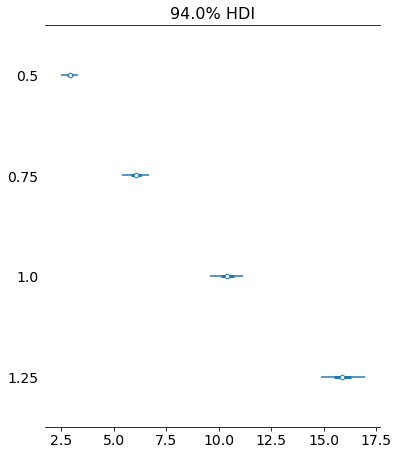

In [26]:
import arviz as az

# intercept_mean = np.mean(trace_2["posterior"]["Intercept"])
# temp_mean = np.mean(trace_2["posterior"]["temp"]) 
# work_day_mean = np.mean(trace_2["posterior"]["work_day"]) 
# wind_speed_mean = np.mean(trace_2["posterior"]["wind_speed"]) 
# sd_mean = np.mean(trace_2["posterior"]["sd"]) 

# For each price, predict volume and use it to predict profit
temp_distribution_map = {}
for temp in [0.5, 0.75, 1, 1.25]:
    pred_mean = (intercept_mean + temp_mean * temp + work_day_mean + wind_speed_mean)
    pred_distribution = np.random.normal(pred_mean, sd_mean, size=1000)
    temp_pred = temp * pred_distribution
    temp_distribution_map.update({temp: temp_pred})
    
# Draw a forest plot of predicted profit for all prices
pm.forestplot(temp_distribution_map)
plt.show()



In [27]:
# # Calculate and print HPD of predicted profit for the optimal temparature
opt_hpd = az.hdi(temp_distribution_map[1.25], credible_interval=0.99)
print(opt_hpd)


[14.84109674 16.95054168]
